In [1]:
import sys
#sys.path.insert(1, '/home/santolam/MyPythonLibrary/MAR-RECAP/libmar/')
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
#sys.path.insert(1, '/Users/santolam/Documents/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from scipy.stats import pearsonr
import cartopy.crs as ccrs

In [2]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [3]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [ ]:
domain_2 = 'GRp'

In [ ]:
sourceData_merra = '/bettik/PROJECTS/pr-regional-climate/fainx/MERRA/'
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [6]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [10]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le forage 2025")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

lat_jasg = ds_lat[iY, iX].item()
lon_jasg = ds_lon[iY, iX].item()

Caratéristique de la maille MAR ou se trouve le forage 2025
Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781
Altitude : 5300.28369140625


In [11]:
ds = xr.open_mfdataset(sourceData_merra + "MERRA2_401.tavgM_2d_aer_Nx.202109.SUB.nc")

In [12]:
ds = xr.open_mfdataset(sourceData_merra + "MERRA2_401.tavgM_2d_aer_Nx.202109.SUB.nc").sel(lon=slice(70.625,73.75)).sel(lat=slice(37.5, 39.5))

In [13]:
ds_merra = xr.open_mfdataset(sourceData_merra + "MERRA2*.nc").load()

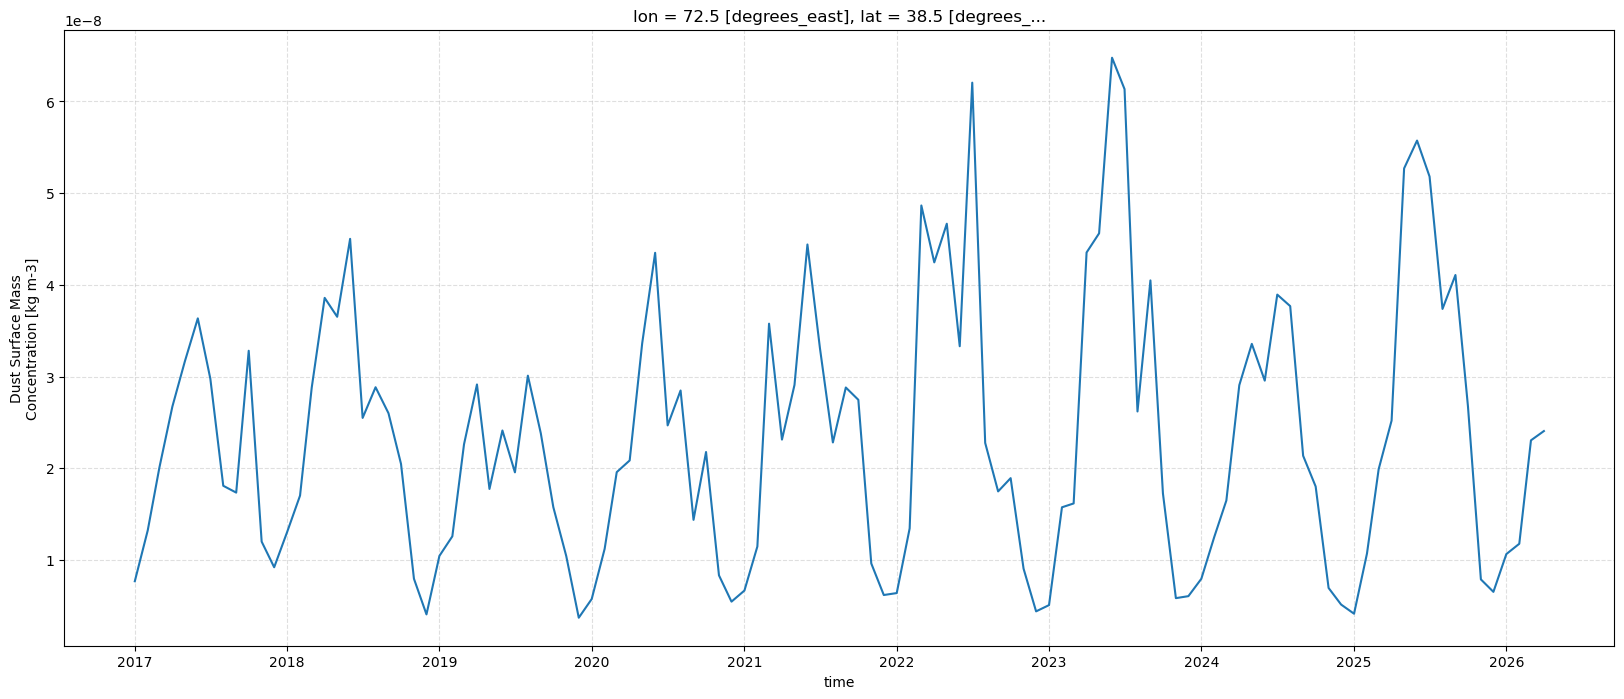

In [14]:
fig, ax = plt.subplots(figsize=(20, 8))  

ds_merra.sel(lat=lat_jasg, method="nearest").sel(lon=lon_jasg, method="nearest").sel(time=slice("2017", "2026")).DUSMASS.plot(ax=ax)

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

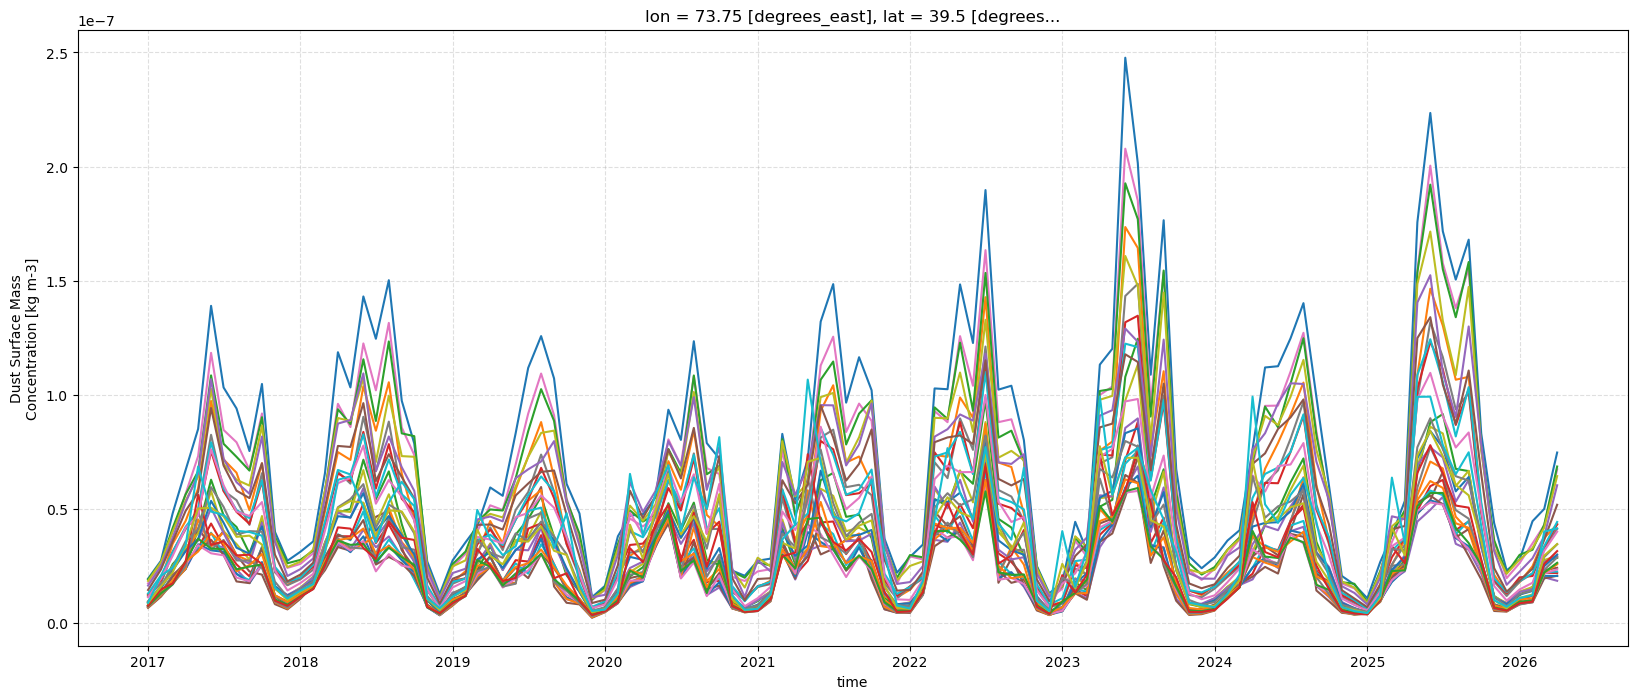

In [15]:
ds = ds_merra.sel(lon=slice(70.625,73.75)).sel(lat=slice(37.5, 39.5))

fig, ax = plt.subplots(figsize=(20, 8))

for lat in ds.lat.values:
    for lon in ds.lon.values:
        ds.sel(lat=lat, lon=lon).sel(time=slice("2017", "2026")).DUSMASS.plot(ax=ax)

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

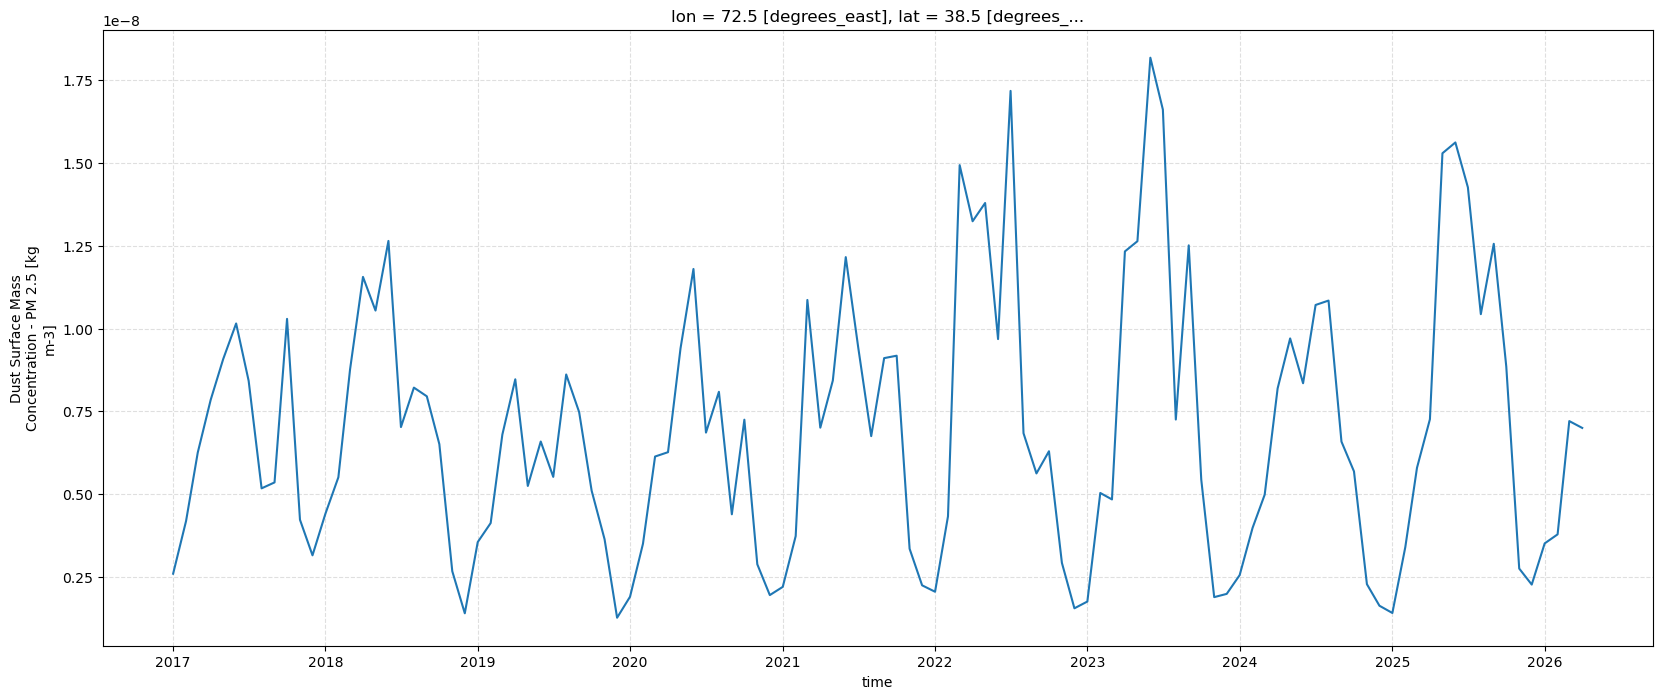

In [16]:
fig, ax = plt.subplots(figsize=(20, 8))  

ds_merra.sel(lat=lat_jasg, method="nearest").sel(lon=lon_jasg, method="nearest").sel(time=slice("2017", "2026")).DUSMASS25.plot(ax=ax)

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

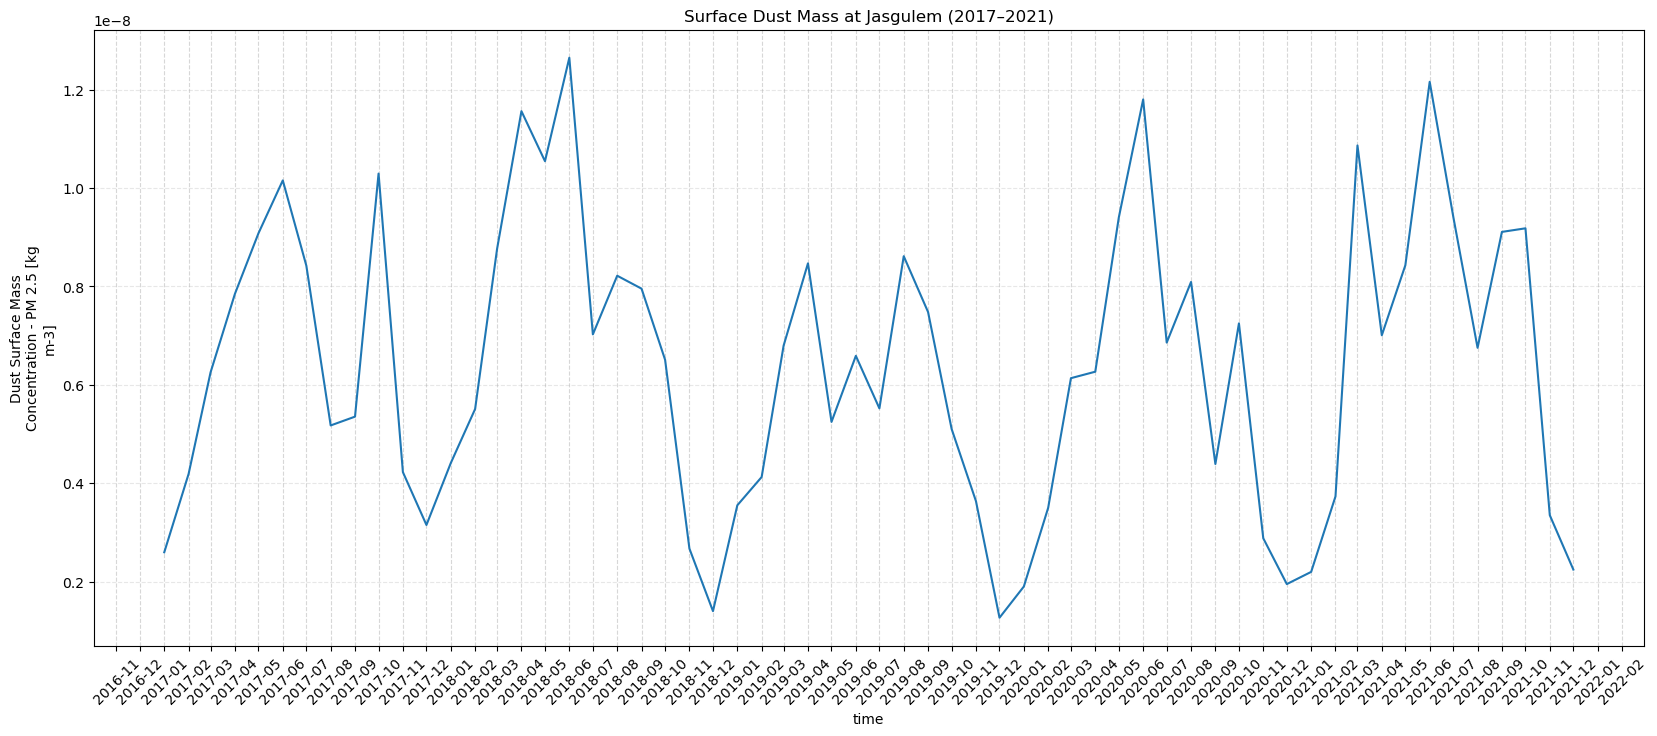

In [17]:
fig, ax = plt.subplots(figsize=(20, 8))  

ds_merra.sel(lat=lat_jasg, method="nearest").sel(lon=lon_jasg, method="nearest").sel(time=slice("2017", "2021")).DUSMASS25.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.5)
ax.grid(True, which="major", axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=45)
ax.set_title("Surface Dust Mass at Jasgulem (2017–2021)")

plt.show()

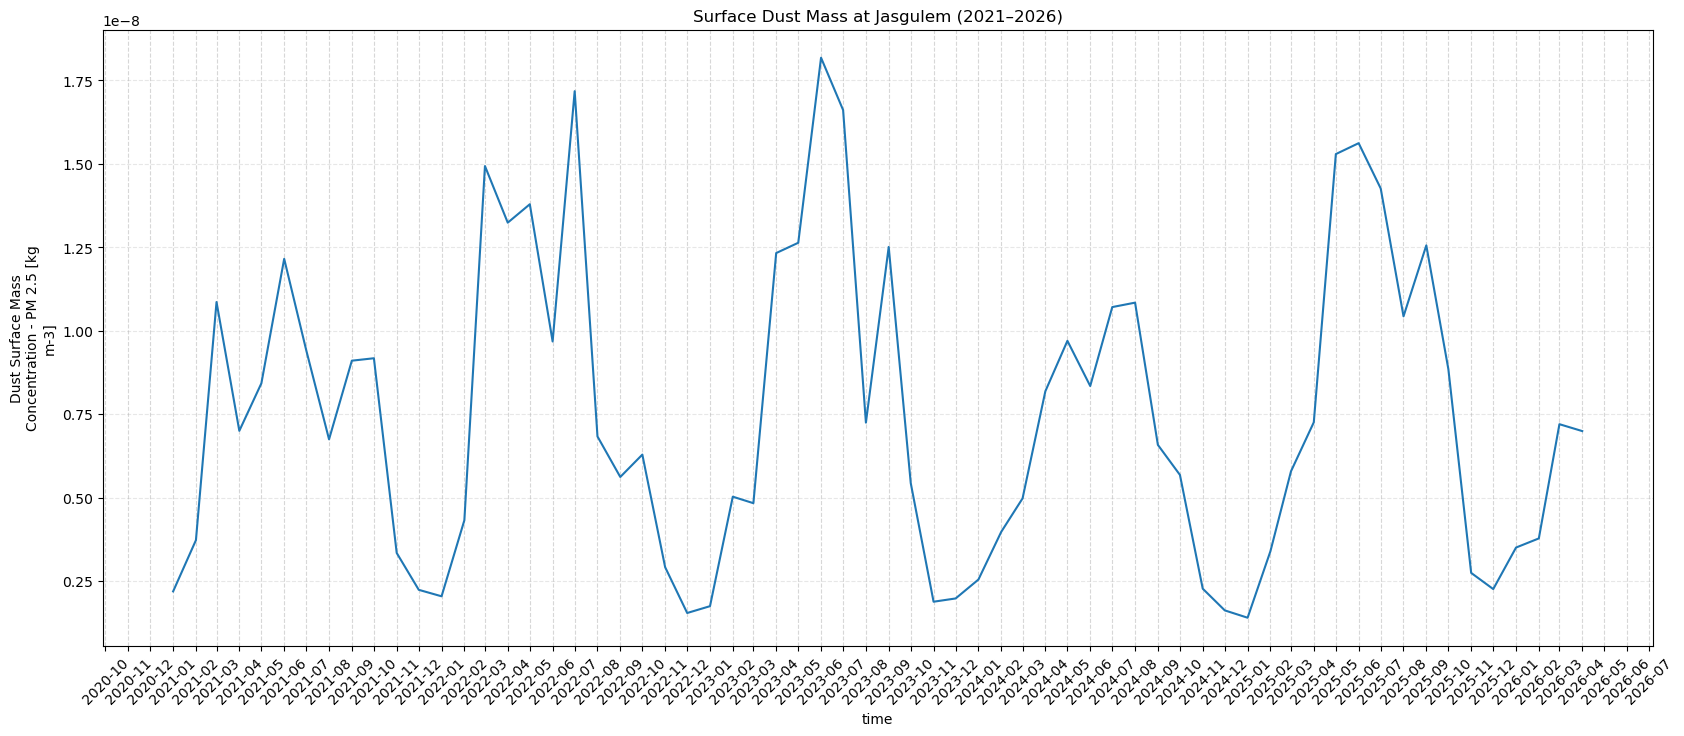

In [18]:
fig, ax = plt.subplots(figsize=(20, 8))  

ds_merra.sel(lat=lat_jasg, method="nearest").sel(lon=lon_jasg, method="nearest").sel(time=slice("2021", "2026")).DUSMASS25.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.5)
ax.grid(True, which="major", axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=45)
ax.set_title("Surface Dust Mass at Jasgulem (2021–2026)")

plt.show()

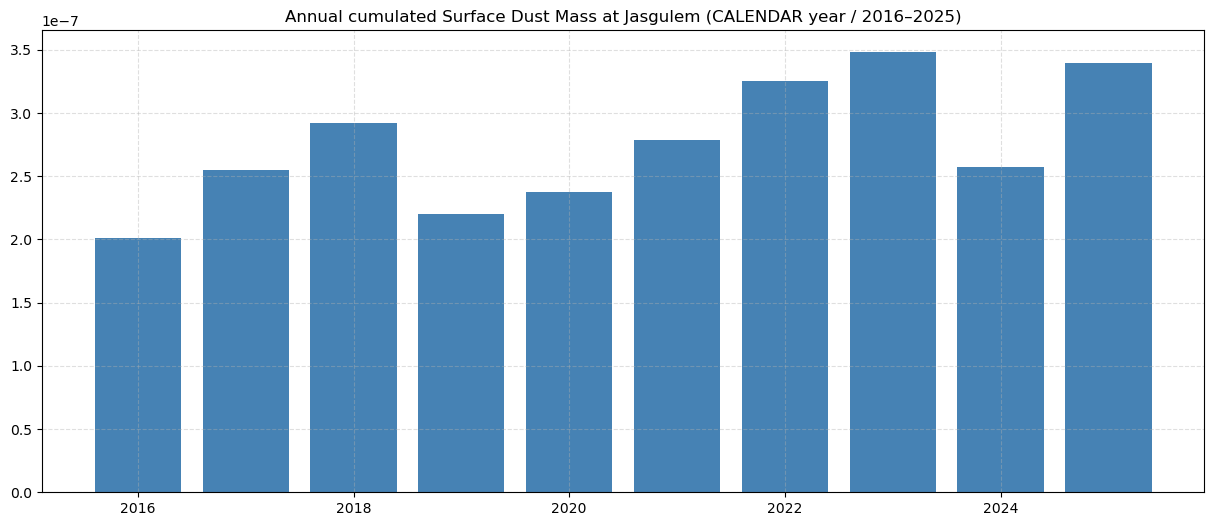

In [19]:
ds=ds_merra.DUSMASS.sel(lat=lat_jasg, method="nearest").sel(lon=lon_jasg, method="nearest").sel(time=slice("2016", "2025")).groupby("time.year").sum()

fig, ax = plt.subplots(figsize=(15, 6))  


ax.bar(
    ds["year"].year,
    ds.values,
    color="steelblue"
)

ax.set_title("Annual cumulated Surface Dust Mass at Jasgulem (CALENDAR year / 2016–2025)")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


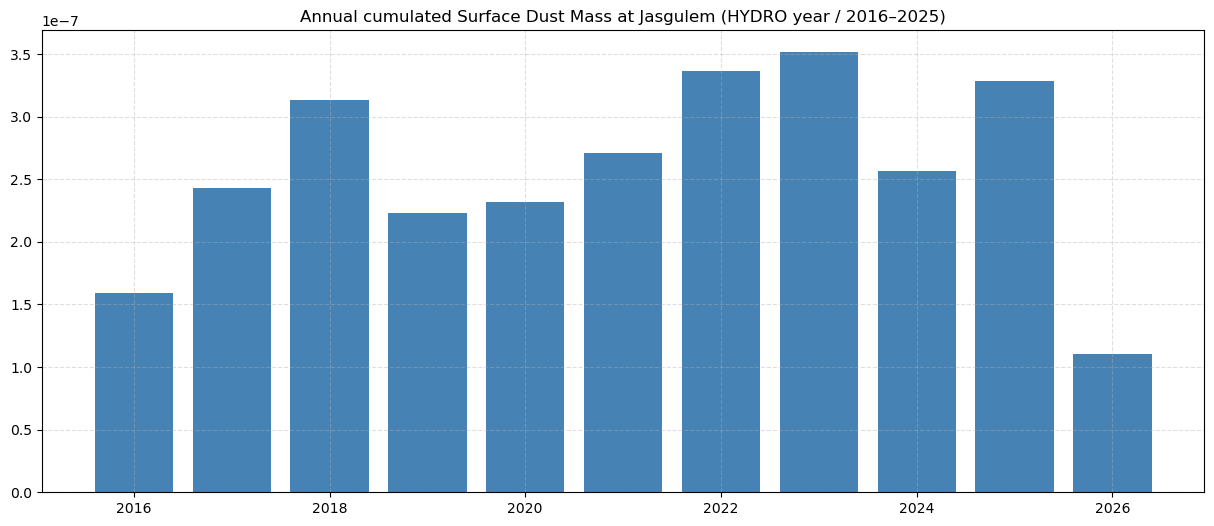

In [42]:
ds=ds_merra.DUSMASS.sel(lat=lat_jasg, method="nearest").sel(lon=lon_jasg, method="nearest").sel(time=slice("2016", "2025")).resample(time="A-SEP").sum()

fig, ax = plt.subplots(figsize=(15, 6))  


ax.bar(
    ds["time"].dt.year,
    ds.values,
    color="steelblue"
)

ax.set_title("Annual cumulated Surface Dust Mass at Jasgulem (HYDRO year / 2016–2025)")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

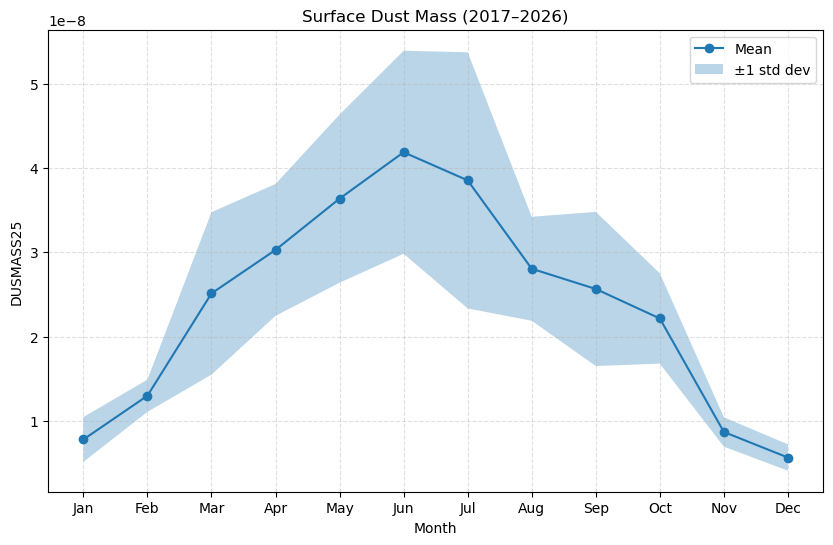

In [133]:
ds = ds_merra.sel(lat=lat_jasg, method="nearest").sel(lon=lon_jasg, method="nearest").sel(time=slice("2017", "2026")).DUSMASS
ds_mean = ds.groupby("time.month").mean()
ds_std  = ds.groupby("time.month").std()


months = np.arange(1, 13)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(months, ds_mean, marker="o", label="Mean")
ax.fill_between(
    months,
    ds_mean - ds_std,
    ds_mean + ds_std,
    alpha=0.3,
    label="±1 std dev"
)

ax.set_xticks(months)
ax.set_xticklabels([
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
])

ax.set_title("Surface Dust Mass (2017–2026)")
ax.set_xlabel("Month")
ax.set_ylabel("DUSMASS25")

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.show()

/tmp/ipykernel_967973/3079226394.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


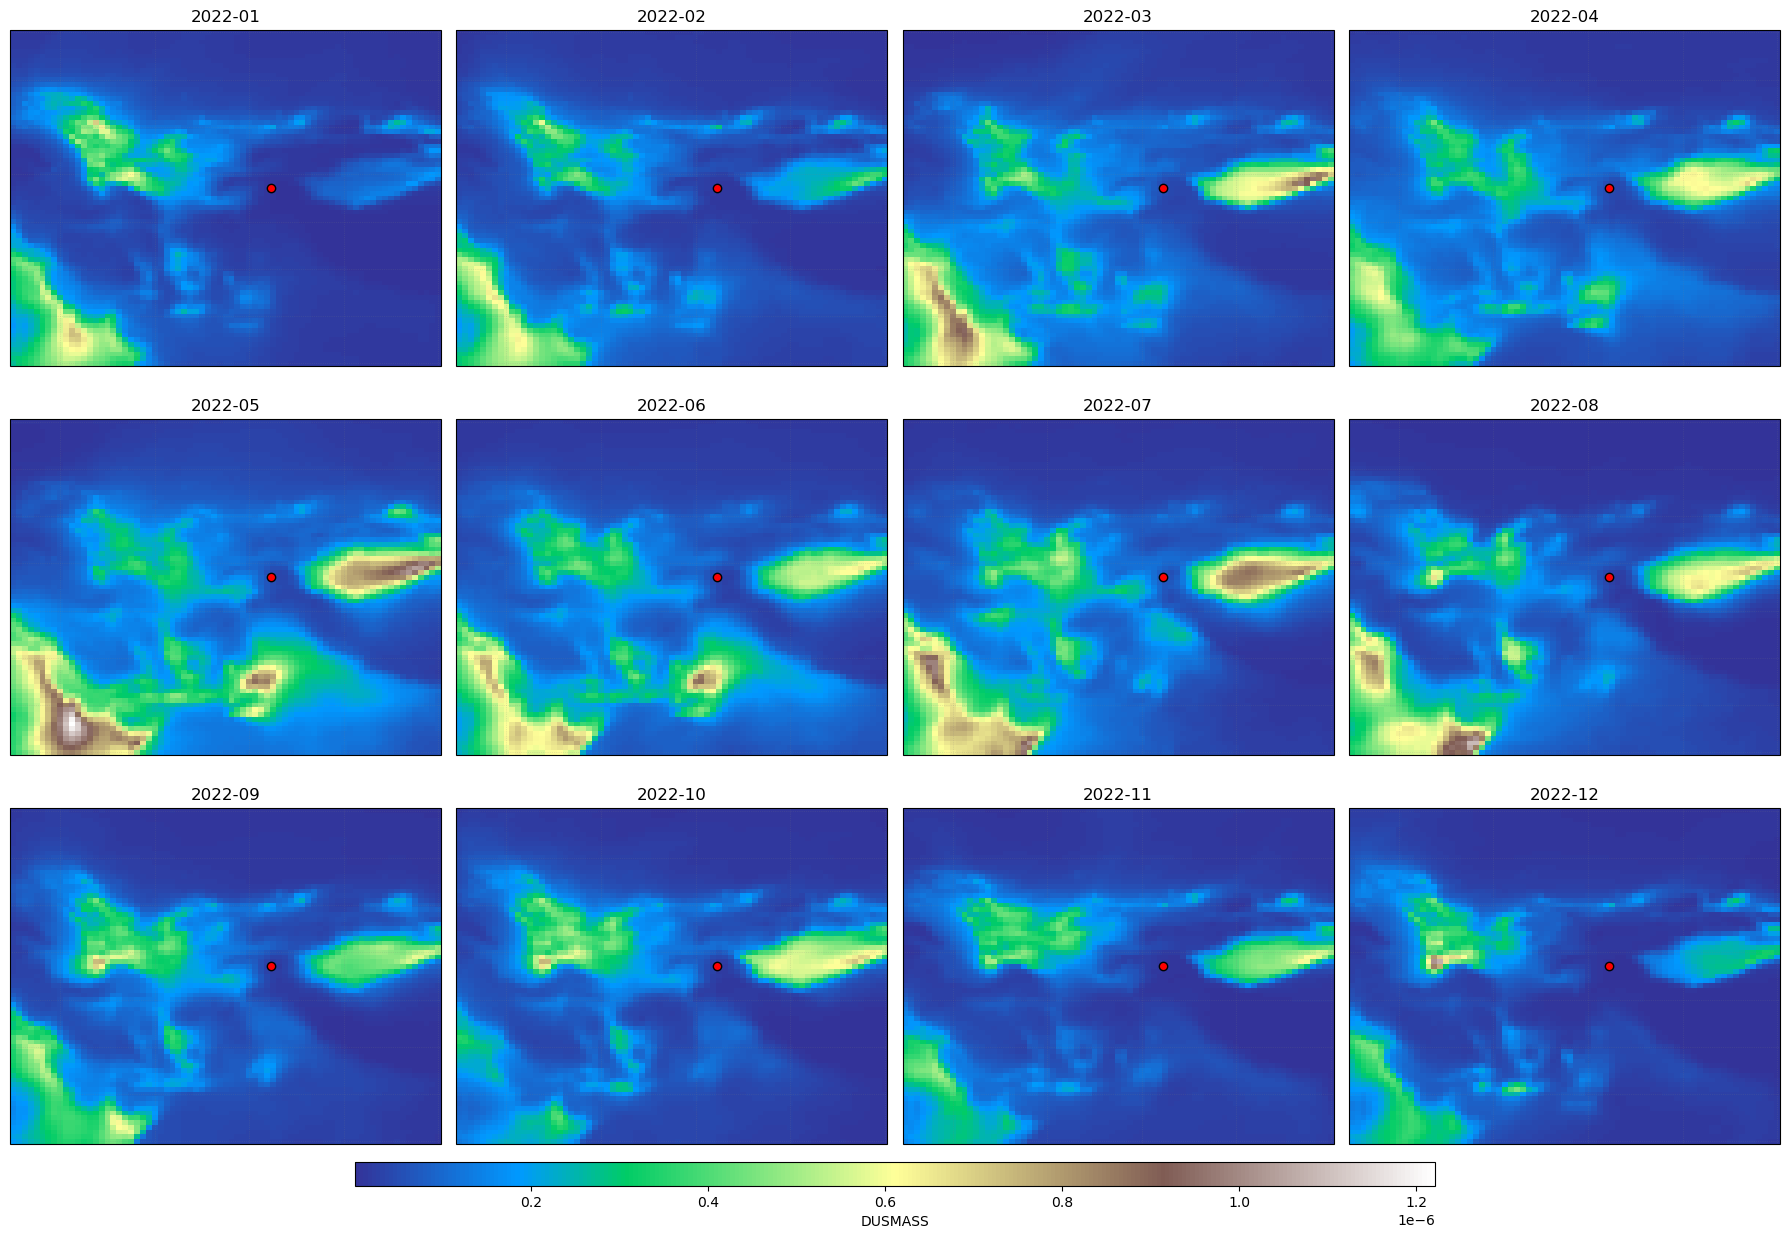

In [120]:
ds = ds_merra.sel(time="2022")

vmin = ds.DUSMASS.min().values
vmax = ds.DUSMASS.max().values

norm_local = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for i, ax in enumerate(axes):
   
    da = ds.DUSMASS.isel(time=i)

    # --- champ principal ---
    da.plot(
        ax=ax,
        x="lon",
        y="lat",
        cmap=cmap_mod,
        norm=norm_local,
        add_colorbar=False
    )

    # --- point Jasgulem ---
    ax.plot(
        jasg_lon, jasg_lat,
        marker='o', markersize=6,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree()
    )

    # --- mise en forme ---
    # ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())
    ax.set_title(str(da.time.values)[:7])  # YYYY-MM

    gl = ax.gridlines(draw_labels=False,
                      linewidth=0.5, color="gray", alpha=0.3, linestyle=":")

# --- colorbar commune ---
cbar_ax = fig.add_axes([0.2, 0, 0.6, 0.02])  
# [left, bottom, width, height]

cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_local, cmap=cmap_mod),
    cax=cbar_ax,
    orientation="horizontal"
)

cbar.set_label("DUSMASS")

plt.tight_layout()
plt.show()

/tmp/ipykernel_967973/235083660.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


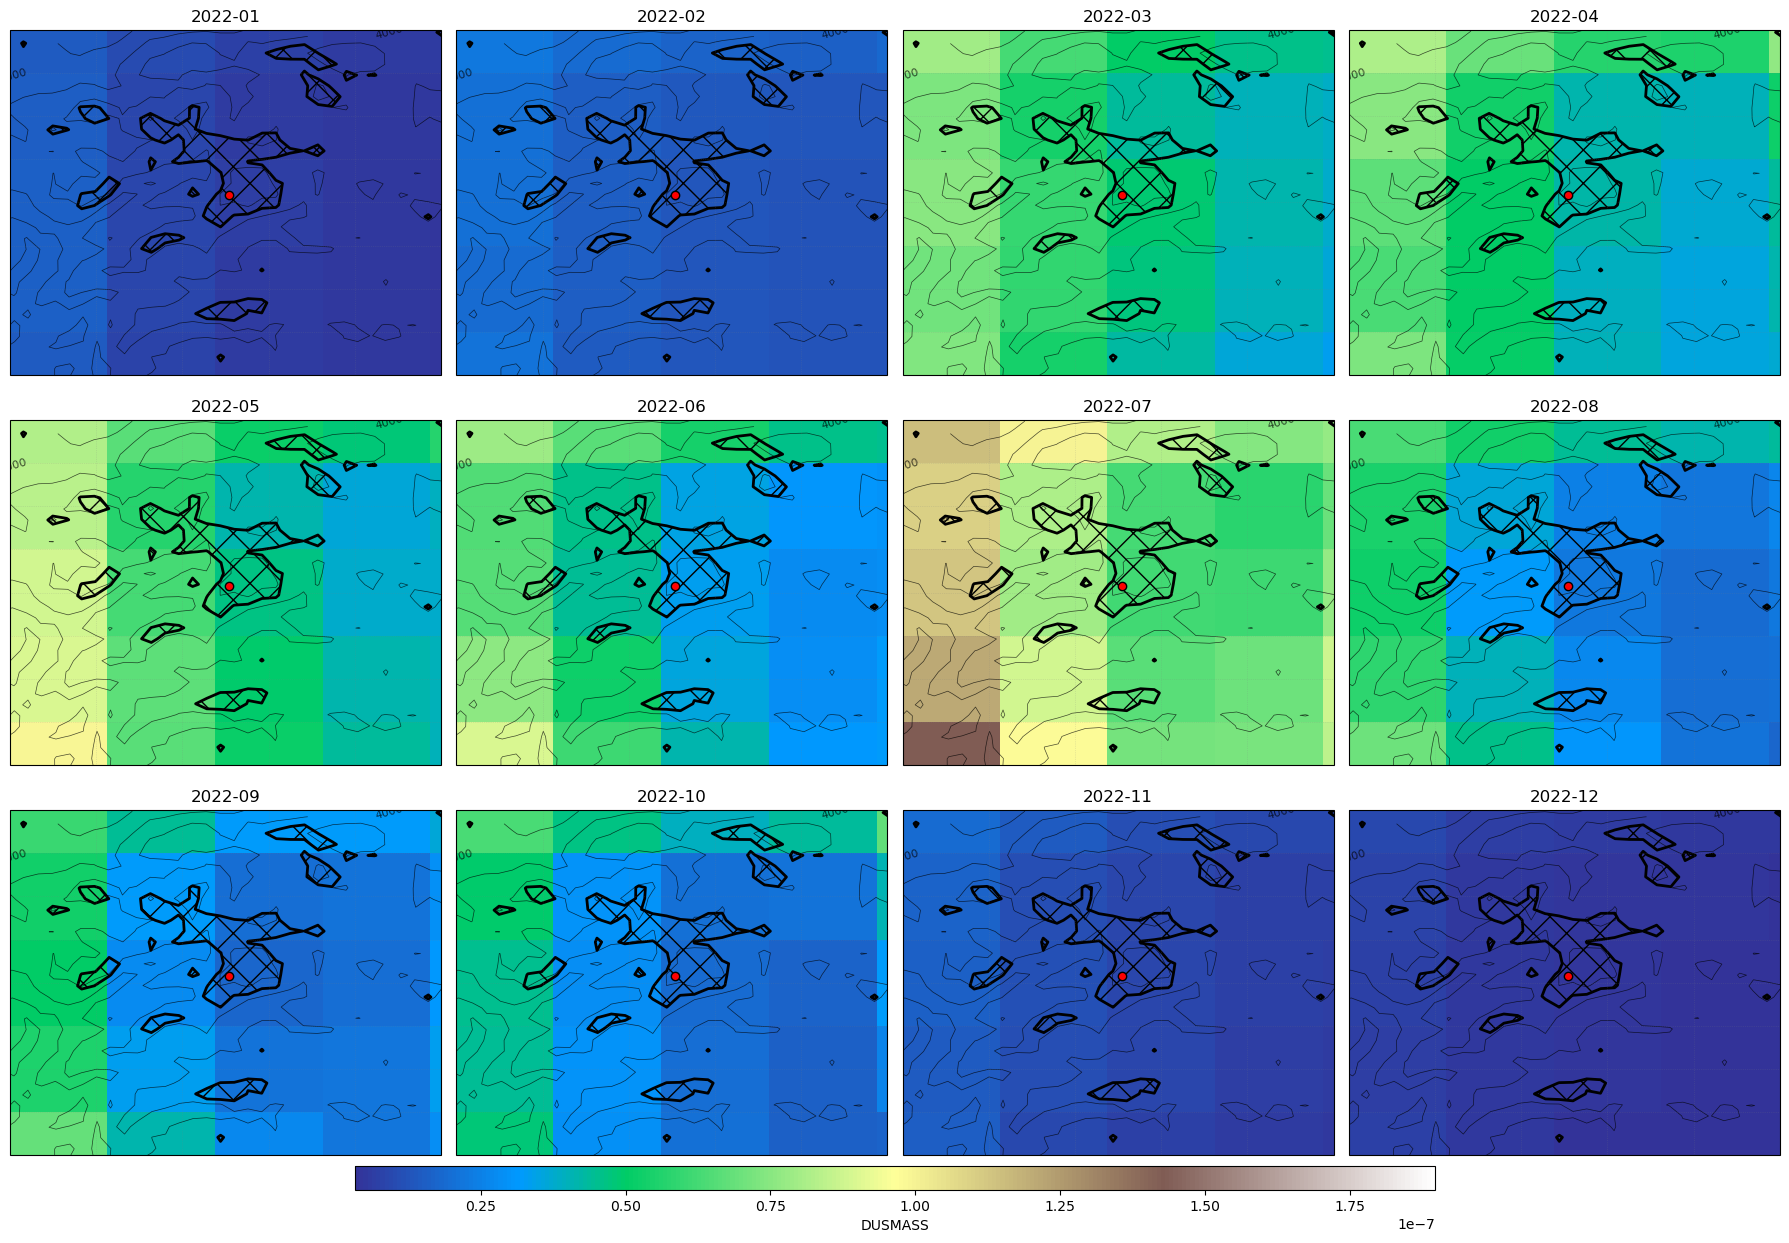

In [101]:
ds = ds_merra.sel(lon=slice(70.625,73.75)).sel(lat=slice(37.5, 39.5)).sel(time="2022")

vmin = ds.DUSMASS.min().values
vmax = ds.DUSMASS.max().values

norm_local = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for i, ax in enumerate(axes):
   
    da = ds.DUSMASS.isel(time=i)

    # --- champ principal ---
    da.plot(
         ax=ax,
        x="lon",
        y="lat",
        cmap=cmap_mod,
        norm=norm_local,
        add_colorbar=False
    )

    # --- ICE hatching ---
    ICE1 = ax.contourf(
        ds_lon, ds_lat, ds_ICE,
        levels=[10, ice_level, 100],
        hatches=['', 'X', 'X'],
        colors="none",
        transform=ccrs.PlateCarree()
    )

    # --- contours SH ---
    SH1 = ax.contour(
        ds_lon, ds_lat, ds_SH,
        levels=[1000,2000,3000,4000,5000,6000,7000],
        colors="k", linewidths=0.5, alpha=0.7,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH1, inline=True, fontsize=8, fmt="%d")

    # --- contour ICE ---
    ICE2 = ax.contour(
        ds_lon, ds_lat, ds_ICE,
        levels=[ice_level],
        colors="black", linewidths=2.0,
        transform=ccrs.PlateCarree()
    )

    # --- point Jasgulem ---
    ax.plot(
        jasg_lon, jasg_lat,
        marker='o', markersize=6,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree()
    )

    # --- mise en forme ---
    ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())
    ax.set_title(str(da.time.values)[:7])  # YYYY-MM

    gl = ax.gridlines(draw_labels=False,
                      linewidth=0.5, color="gray", alpha=0.3, linestyle=":")

# --- colorbar commune ---
cbar_ax = fig.add_axes([0.2, 0, 0.6, 0.02])  
# [left, bottom, width, height]

cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_local, cmap=cmap_mod),
    cax=cbar_ax,
    orientation="horizontal"
)

cbar.set_label("DUSMASS")

plt.tight_layout()
plt.show()

/tmp/ipykernel_967973/3455850126.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


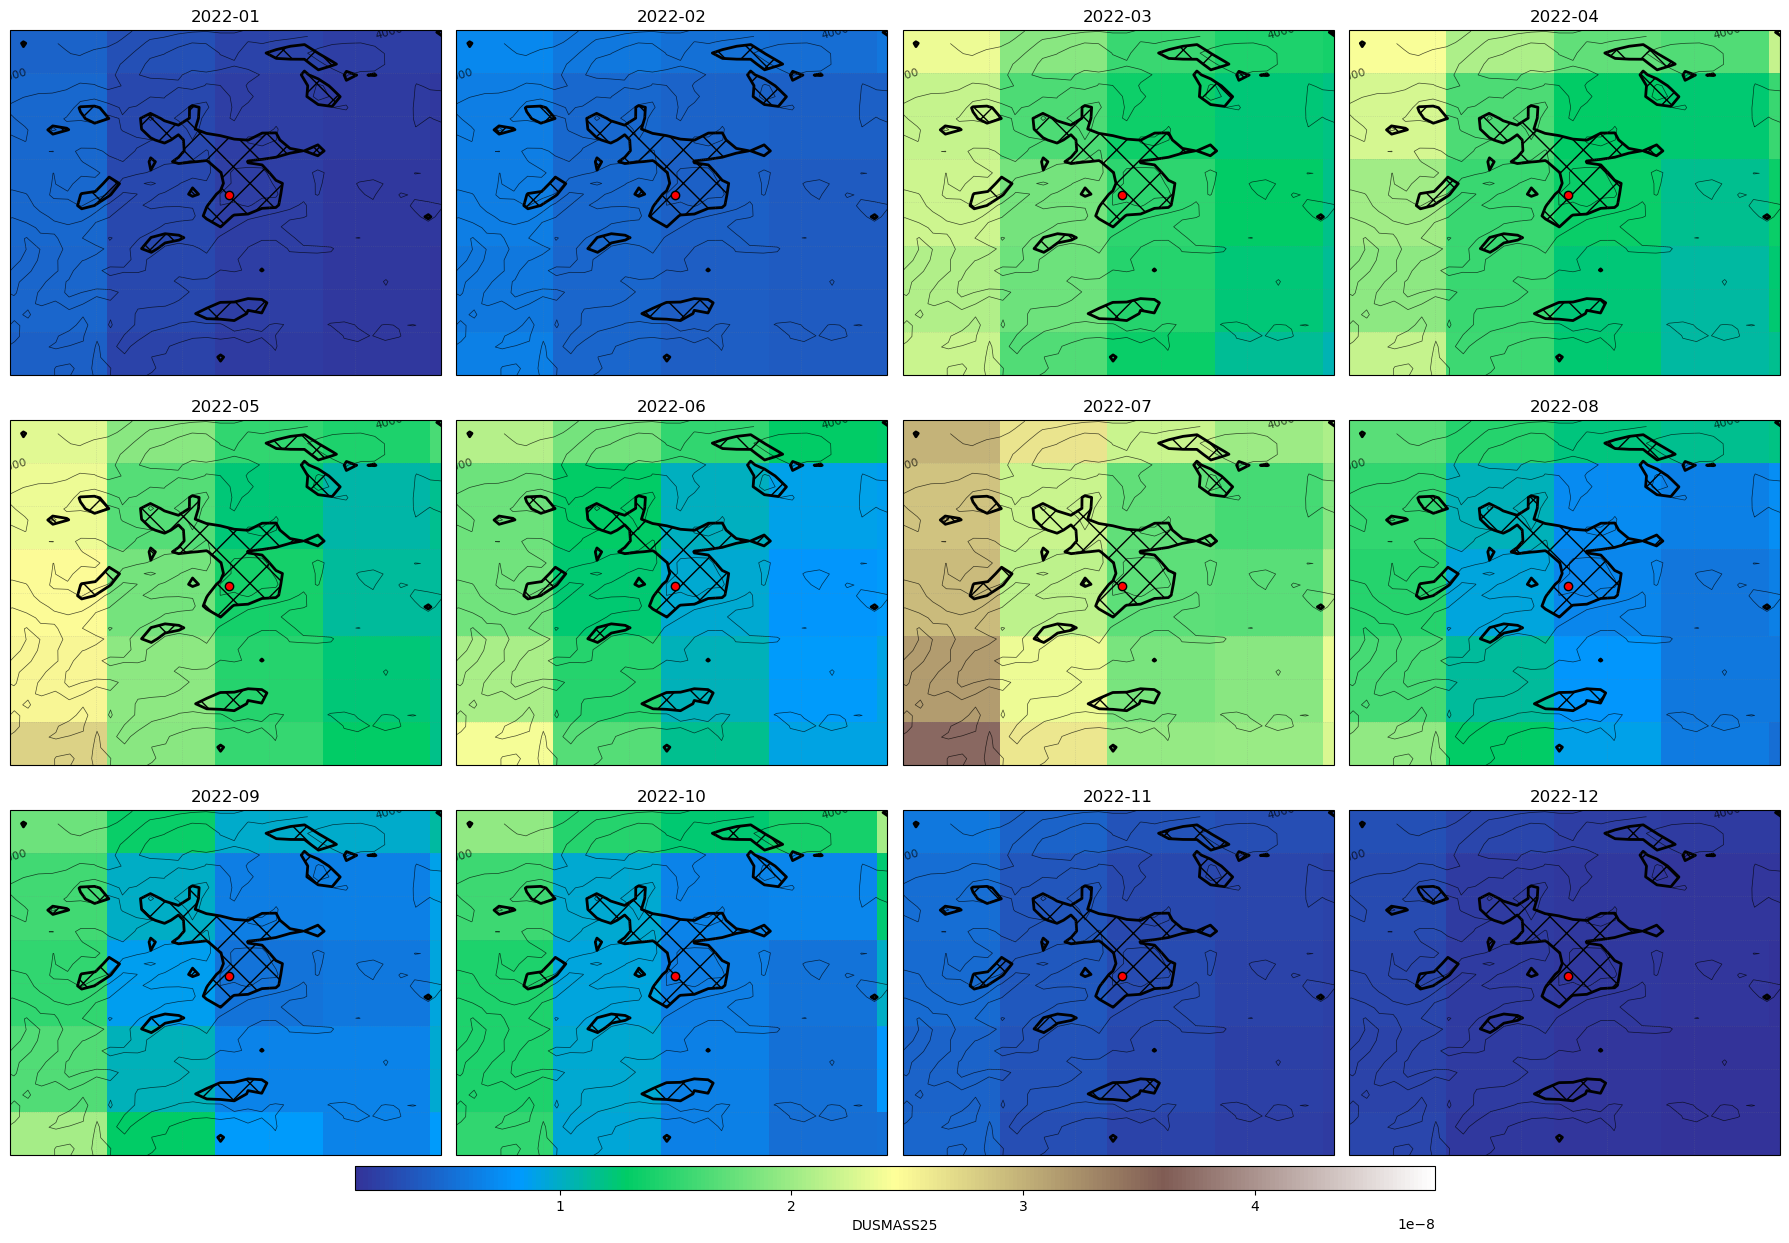

In [102]:
ds = ds_merra.sel(lon=slice(70.625,73.75)).sel(lat=slice(37.5, 39.5)).sel(time="2022")

vmin = ds.DUSMASS25.min().values
vmax = ds.DUSMASS25.max().values

norm_local = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for i, ax in enumerate(axes):
   
    da = ds.DUSMASS25.isel(time=i)

    # --- champ principal ---
    da.plot(
         ax=ax,
        x="lon",
        y="lat",
        cmap=cmap_mod,
        norm=norm_local,
        add_colorbar=False
    )

    # --- ICE hatching ---
    ICE1 = ax.contourf(
        ds_lon, ds_lat, ds_ICE,
        levels=[10, ice_level, 100],
        hatches=['', 'X', 'X'],
        colors="none",
        transform=ccrs.PlateCarree()
    )

    # --- contours SH ---
    SH1 = ax.contour(
        ds_lon, ds_lat, ds_SH,
        levels=[1000,2000,3000,4000,5000,6000,7000],
        colors="k", linewidths=0.5, alpha=0.7,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH1, inline=True, fontsize=8, fmt="%d")

    # --- contour ICE ---
    ICE2 = ax.contour(
        ds_lon, ds_lat, ds_ICE,
        levels=[ice_level],
        colors="black", linewidths=2.0,
        transform=ccrs.PlateCarree()
    )

    # --- point Jasgulem ---
    ax.plot(
        jasg_lon, jasg_lat,
        marker='o', markersize=6,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree()
    )

    # --- mise en forme ---
    ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())
    ax.set_title(str(da.time.values)[:7])  # YYYY-MM

    gl = ax.gridlines(draw_labels=False,
                      linewidth=0.5, color="gray", alpha=0.3, linestyle=":")

# --- colorbar commune ---
cbar_ax = fig.add_axes([0.2, 0, 0.6, 0.02])  
# [left, bottom, width, height]

cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_local, cmap=cmap_mod),
    cax=cbar_ax,
    orientation="horizontal"
)

cbar.set_label("DUSMASS25")

plt.tight_layout()
plt.show()